In [2]:
import nltk
import random
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from sklearn import metrics

Loading dataset


In [3]:
nltk.download('conll2002')

[nltk_data] Downloading package conll2002 to /root/nltk_data...
[nltk_data]   Package conll2002 is already up-to-date!


True

In [4]:
corpus = nltk.corpus.conll2002.iob_sents()

In [5]:
data = []
for cor in corpus:
    sent, _, tag = list(zip(*cor))
    data.append([sent, tag])

In [6]:
data[0]

[('Sao',
  'Paulo',
  '(',
  'Brasil',
  ')',
  ',',
  '23',
  'may',
  '(',
  'EFECOM',
  ')',
  '.'),
 ('B-LOC', 'I-LOC', 'O', 'B-LOC', 'O', 'O', 'O', 'O', 'O', 'B-ORG', 'O', 'O')]

In [7]:
flatten = lambda l: [item for sublist in l for item in sublist]

sents, tags = list(zip(*data))
vocab  = list(set(flatten(sents)))
tagset = list(set(flatten(tags)))

In [8]:
tagset

['B-LOC', 'I-PER', 'B-PER', 'B-ORG', 'I-LOC', 'O', 'B-MISC', 'I-MISC', 'I-ORG']

In [9]:
word2index = {'<UNK>': 0, '<DUMMY>': 1}
for v in vocab:
    if word2index.get(v) is None:
        word2index[v] = len(word2index)
index2word = {v:k for k, v in word2index.items()}

tag2index = {}
for v in tagset:
    if tag2index.get(v) is None:
        tag2index[v] = len(tag2index)
index2tag = {v:k for k, v in tag2index.items()}

In [10]:
window_size = 2
windows = []

In [11]:
for sample in data:
    dummy = ['<DUMMY>'] * window_size
    text  = sample[0] #first tuple containing the sentence; sample[1] contains the tags
    padded_text = dummy + list(sample[0]) + dummy
    window = list(nltk.ngrams(padded_text, window_size * 2 + 1))

    windows.extend([[list(window[i]), sample[1][i]] for i in range(len(sample[0]))])

In [12]:
random.shuffle(windows)

train_data = windows[:int(len(windows) * 0.9)]
test_data  = windows[int(len(windows) * 0.9):]

In [13]:
def prepare_sequence(seq, word2index):
    idxs = list(map(lambda w: word2index[w] if word2index.get(w) is not None else word2index["<UNK>"], seq))
    return torch.LongTensor(idxs)


In [14]:
def prepare_tag(tag_seq, tag2index, device):
    if isinstance(tag_seq, str):
        raise ValueError(f"Expected list of tags like ['B-LOC', 'O'], got string: '{tag_seq}'")
    idxs = []
    for t in tag_seq:
        if t not in tag2index:
            print(f"[WARNING] Unknown tag: '{t}'")
            continue
        idxs.append(tag2index[t])
    return torch.tensor(idxs, dtype=torch.long).to(device)

In [15]:
# generator for the batch better as saves memory
def getBatch(batch_size, train_data):
    random.shuffle(train_data)
    sindex = 0
    eindex = batch_size
    while eindex < len(train_data):
        batch = train_data[sindex:eindex]
        temp  = eindex
        eindex = eindex + batch_size
        sindex = temp
        yield batch

    if eindex >= len(train_data):
        batch = train_data[sindex:]
        yield batch

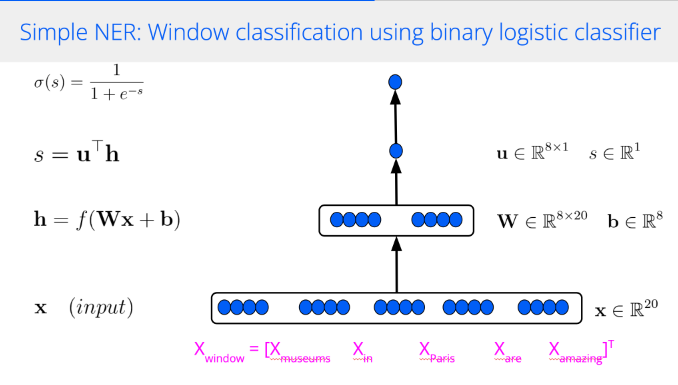

In [16]:
class NER(nn.Module):

    def __init__(self, vocab_size, embed_size, hidden_size, window_size, out_size):
        super(NER, self).__init__()

        self.embed = nn.Embedding(vocab_size, embed_size)
        self.layer1 = nn.Linear(embed_size * (window_size*2+1), hidden_size)
        self.layer2 = nn.Linear(hidden_size, out_size) #predict the probability of each tag
        self.relu   = nn.ReLU()
        self.dropout = nn.Dropout(0.3)

    def forward(self, inputs):
        embeds = self.embed(inputs) #(batch_size, 5, emb_size)
        embeds = embeds.view(-1, embeds.size(1) * embeds.size(2)) #(batch_size, 5 * emb_size)
        h0 = self.dropout(self.relu(self.layer1(embeds)))
        out = self.layer2(h0)
        return out


In [17]:
batch_size = 2
embed_size = 4
hidden_size = 8
num_epochs  = 5

In [18]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [19]:
model = NER(len(word2index), embed_size, hidden_size, window_size, len(tag2index))
model.to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr = 0.001)

In [20]:
model.train()

NER(
  (embed): Embedding(65461, 4)
  (layer1): Linear(in_features=20, out_features=8, bias=True)
  (layer2): Linear(in_features=8, out_features=9, bias=True)
  (relu): ReLU()
  (dropout): Dropout(p=0.3, inplace=False)
)

In [21]:
for epoch in range(num_epochs):
    losses = []
    for i, batch in enumerate(getBatch(batch_size, train_data)):

        x,y = list(zip(*batch))

        inputs = torch.cat([
            prepare_sequence(sent, word2index).view(1, -1).to(device)
            for sent in x
        ])
        targets = torch.cat([prepare_tag([tag_seq] if isinstance(tag_seq, str) else tag_seq, tag2index, device) for tag_seq in y])

        inputs = inputs.to(device)
        targets = targets.to(device)

        preds = model(inputs)
        loss  = criterion(preds, targets)
        losses.append(loss.item())

        model.zero_grad()
        loss.backward()
        optimizer.step()

    print(f"Epoch: {epoch + 1} | Batch: {i: 5.0f} | Loss: {np.mean(losses):.6f}")

Epoch: 1 | Batch:  305269 | Loss: 0.422413
Epoch: 2 | Batch:  305269 | Loss: 0.334688
Epoch: 3 | Batch:  305269 | Loss: 0.312106
Epoch: 4 | Batch:  305269 | Loss: 0.299392
Epoch: 5 | Batch:  305269 | Loss: 0.290276


In [23]:
for_f1_score = []

In [24]:
accuracy = 0

Turning off the dropout

In [25]:
model.eval()

NER(
  (embed): Embedding(65461, 4)
  (layer1): Linear(in_features=20, out_features=8, bias=True)
  (layer2): Linear(in_features=8, out_features=9, bias=True)
  (relu): ReLU()
  (dropout): Dropout(p=0.3, inplace=False)
)

In [29]:
for test in test_data:
    x, y = test[0], test[1]
    input = prepare_sequence(x, word2index).view(1, -1).to(device)
    preds = model(input) #(batch_size, probability over all tagset)

    i = preds.max(1)[1]
    pred = index2tag[i.item()]
    for_f1_score.append([pred, y])
    if pred == y:
        accuracy += 1

print(accuracy / len(test_data) * 100)

92.5823284884578


In [30]:
yhat, y = list(zip(*for_f1_score))

In [31]:
set(yhat)

{'B-LOC', 'B-ORG', 'B-PER', 'I-MISC', 'I-ORG', 'I-PER', 'O'}

In [32]:
print(metrics.classification_report(yhat, y))

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


              precision    recall  f1-score   support

       B-LOC       0.14      0.50      0.22       315
      B-MISC       0.00      0.00      0.00         0
       B-ORG       0.69      0.46      0.55      2095
       B-PER       0.45      0.85      0.59       682
       I-LOC       0.00      0.00      0.00         0
      I-MISC       0.00      1.00      0.00         1
       I-ORG       0.54      0.53      0.54      1030
       I-PER       0.63      0.87      0.73       671
           O       0.99      0.95      0.97     63044

    accuracy                           0.93     67838
   macro avg       0.38      0.57      0.40     67838
weighted avg       0.96      0.93      0.94     67838



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
